# File data

**Important csv files:**
    
    1. Sample_Data_for_GPS2_and_ATF4.csv
    2. Updated_Sample_Sheet.csv
    3. Peak_Calls_with_Control.csv
    4. Peak_Calls_without_Control.csv

1. ``Sample_Data_for_GPS2_and_ATF4.csv``: All the raw fastq files and their corresponding FTP links are listed in the csv file. To add more samples to this analysis, provide the FTP links and name the directory and sample accordingly.

2. ``Updated_Sample_Sheet.csv``: This was used since we had to concatenate some of the raw fastq files before proceeding with the analysis. You still have to add the new sample data here even if the new samples you're adding to the analysis need not be concatenated.

3. ``Peak_Calls_with_Control.csv``: This was done to evaluate if there's significant differences between peaks called with and without control. If you want your newly added samples to be peak called without control use this file.

4. ``Peak_Calls_without_Control.csv``: If you want your newly added samples to be peak called with control, update the columns accordingly in this file.

**Important Directories:**
    
    1. Adipocyte_differentiation
    2. Mito_stress_treatment``
    3. Silencing
    4. ATF4_RNAseq
    5. Older-results

Directories 1 and 3 have only GPS2 and multiqc results. Directory 2 has 4 sub-directories. ``Amino_acid_deprivation`` and ``ER_stress`` subdirectories are ATF4 data. Almost all of the *Plot profiles* would be in the matrix subdirectory of either of these sub-directories. Directory 4 has all the RNA-seq data from public resources. The results from these resources weren't reanalysed, but were just used for comparison.


**Important notebooks:**
    
    1. Peaks Annotation and Plots.Rmd
    2. Geneset_Enrichment_Analysis.Rmd
    3. GeneList_RNAseq.ipynb

Inorder to do Peak annotation and Geneset enrichment analysis, you have to use these scripts because they weren't integrated directly into the snakemake script.

**Scripts**

    1. ChIP_ATF3_and_GPS2_C2C12.snake
    2. ChIP_ATF4_and_GPS2_human.snake
    3. ChIP_ATF4_and_GPS2_mouse.snake

1. ``ChIP_ATF3_and_GPS2_C2C12.snake``: Snakemake pipeline for ATF3 and GPS2 from C2C12. All basic analysis completed.

2. ``ChIP_ATF4_and_GPS2_human.snake``: Snakemake pipeline for ATF4 data from Human and GPS2 from 3T3-L1. This file was just used for aligning to human genome and generating some basic results.

3. ``ChIP_ATF4_and_GPS2_mouse.snake``: This is the master file. Fully completed with all comparison and analysis set up. This is a snakemake script for ATF4 data from MEF cells and GPS2 from 3T3-L1 cell line.

**Opening VS Code**

1. Go to SCC On Demand https://scc-ondemand2.bu.edu/pun/sys/dashboard/

2. Click on `Interactive Apps` tab and select `VS Code Server`

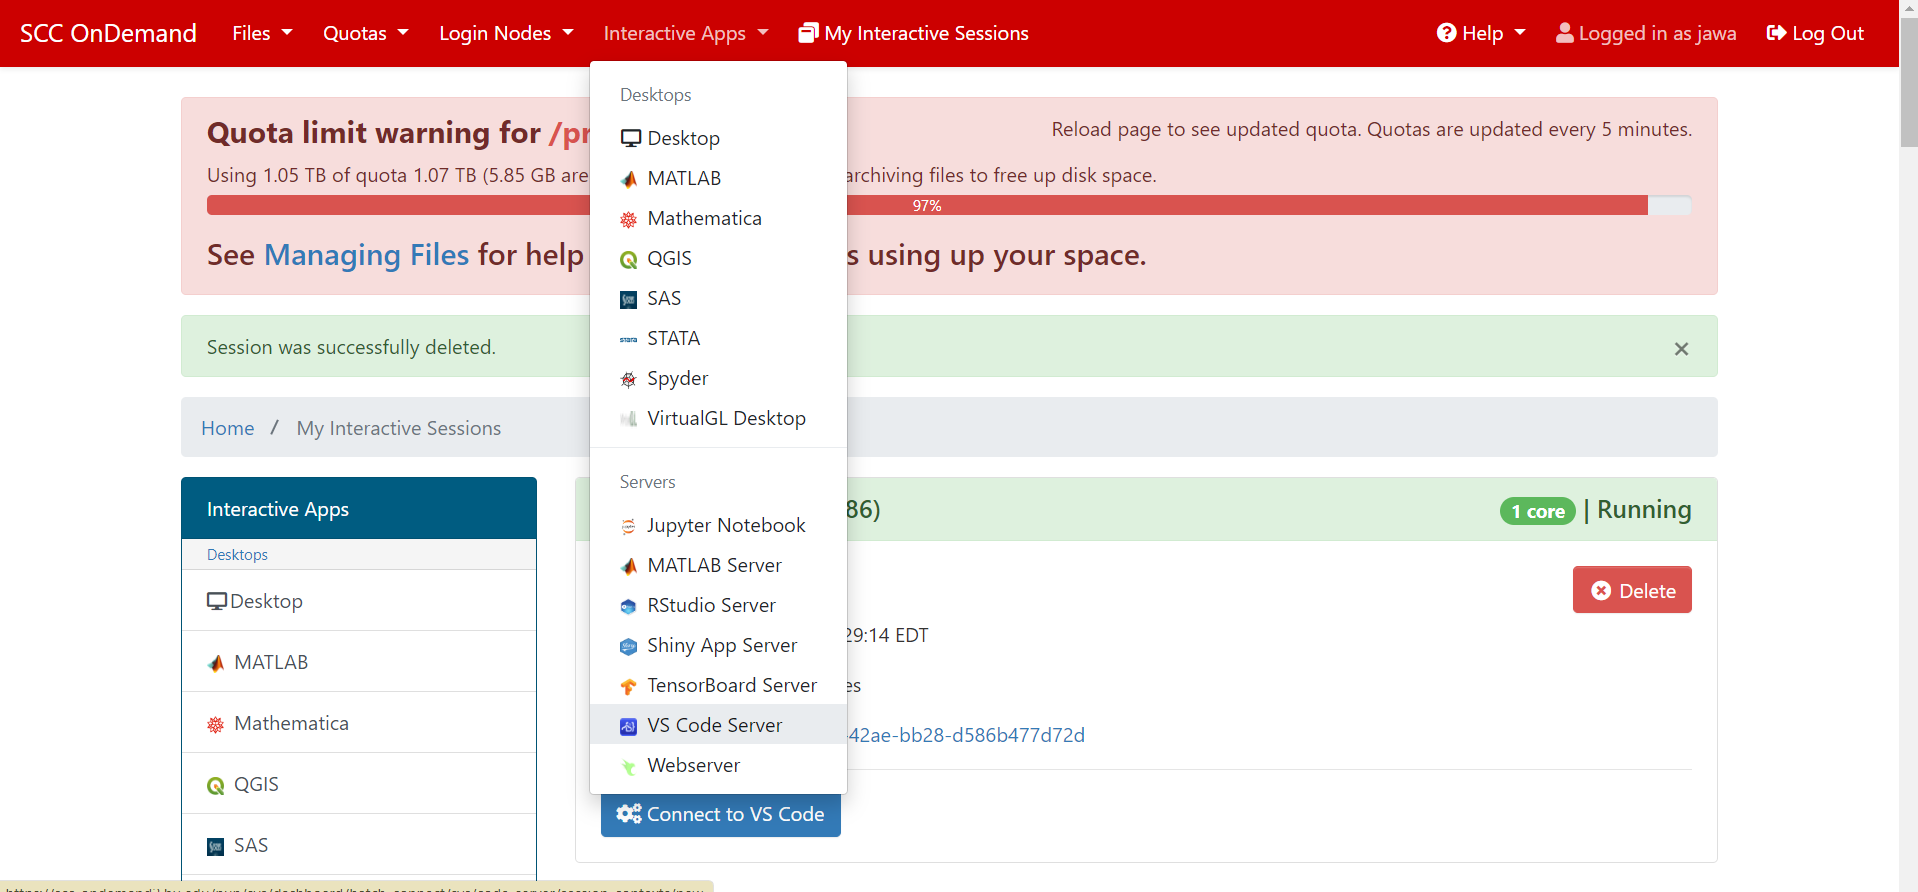

3. Click on `Select Directory` button in the Working Directory field and select the appropriate directory you want to go to. (/projectnb/perissilab/Jawahar/GPS2_ChIPseq_Perissi-Lab)

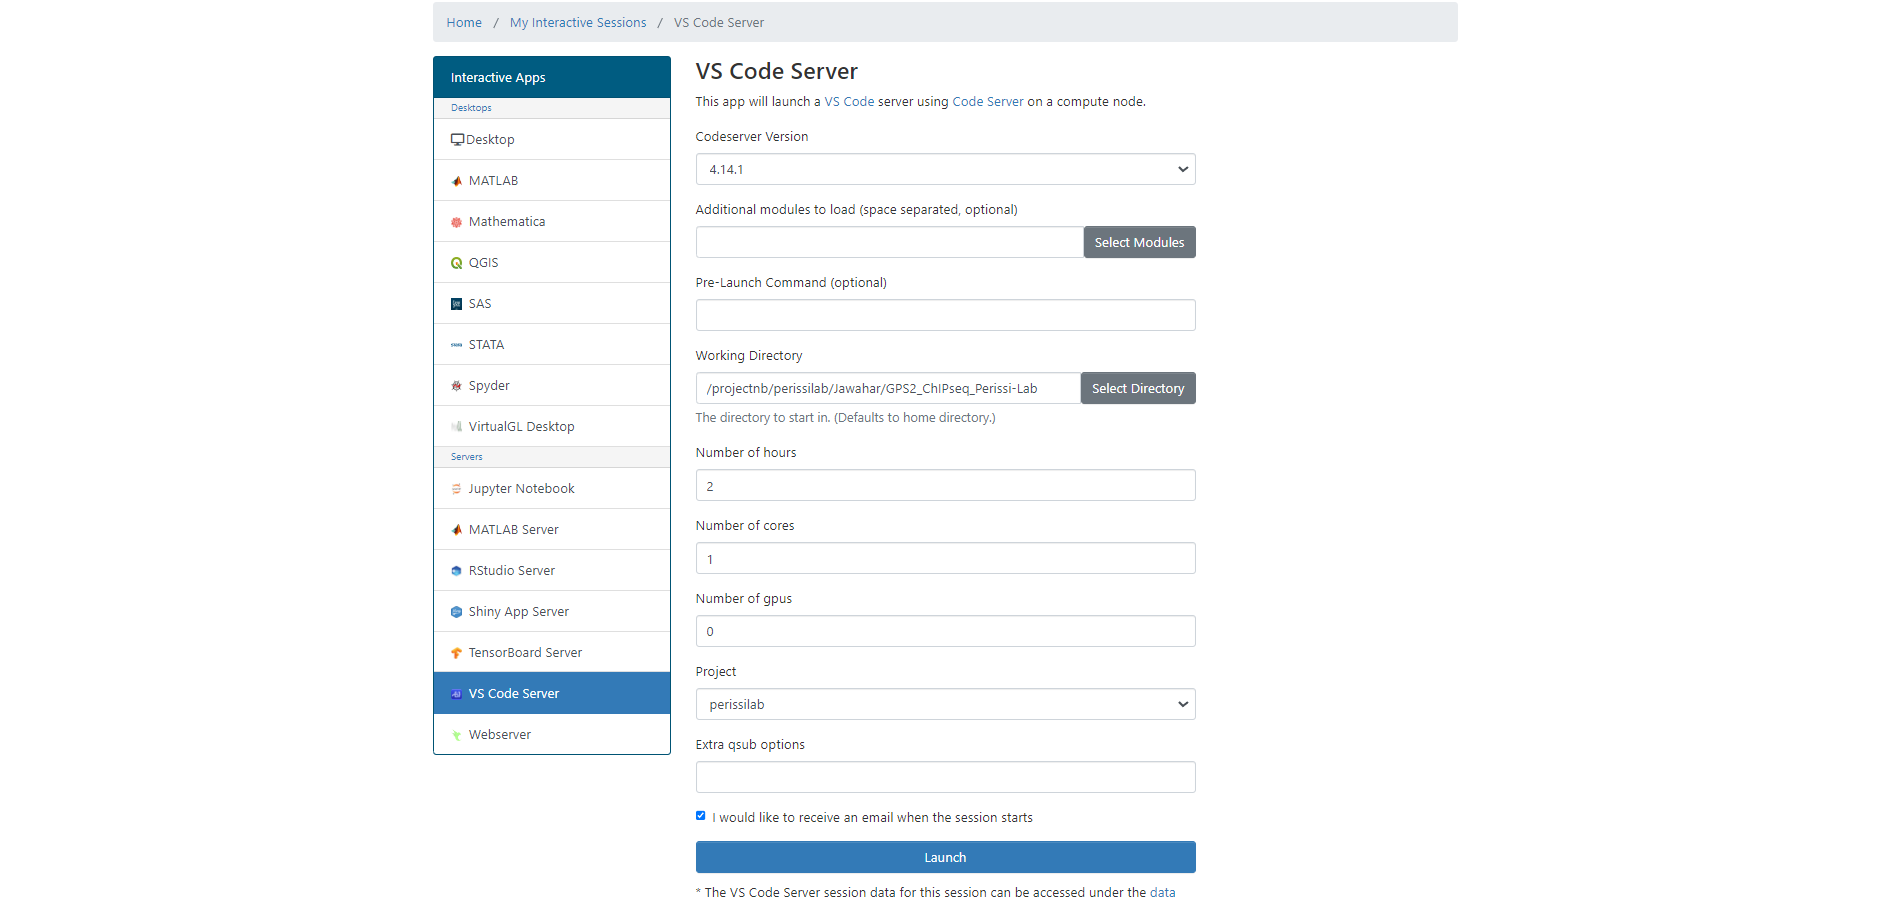

4. Click on *Launch* and you'll see a VS Code Server queued in the `My Interactive Sessions` tab. 

5. It will turn into Green color in a few minutes and you'll see it say Running. Click on **Connect to VS Code**

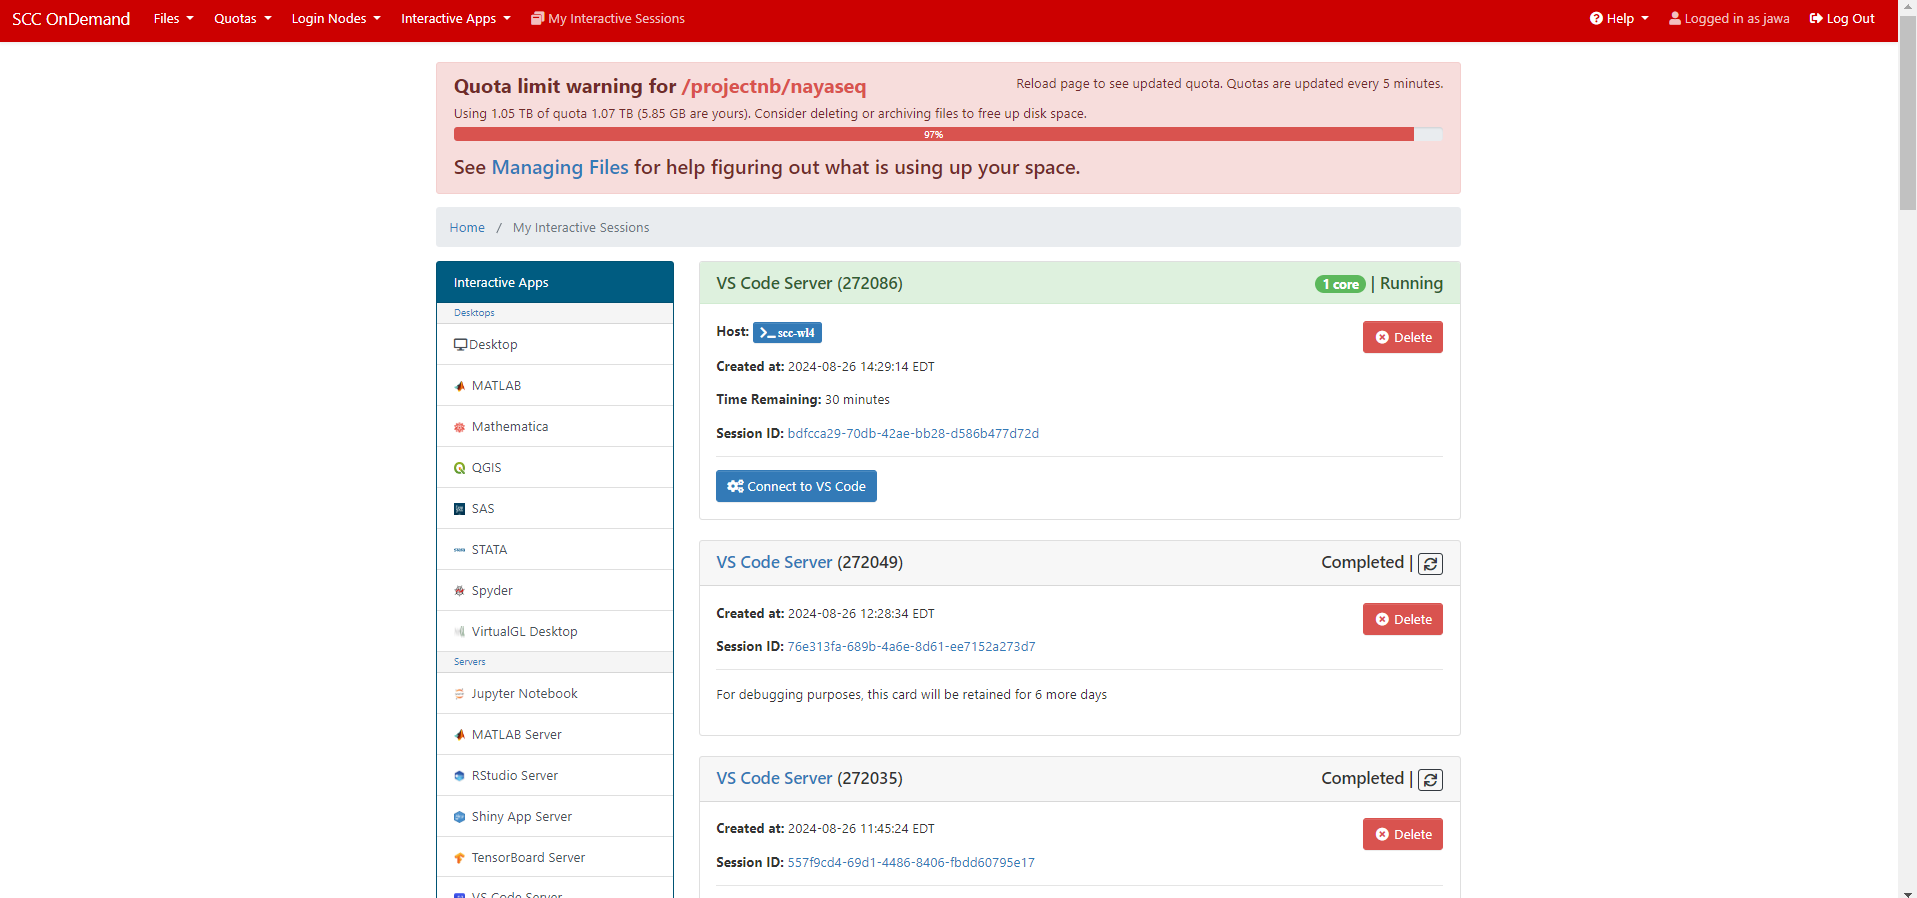

**Executing the snakemake pipeline**

1. Once the VS Code Server is open in a new tab, click on the Hamburger icon on the left top of the screen.

2. Select Terminal > New Terminal

3. A bash session should open in the bottom half of your VS Codescpae.

4. In the terminal, enter 
    
    > conda activate chip_seq

    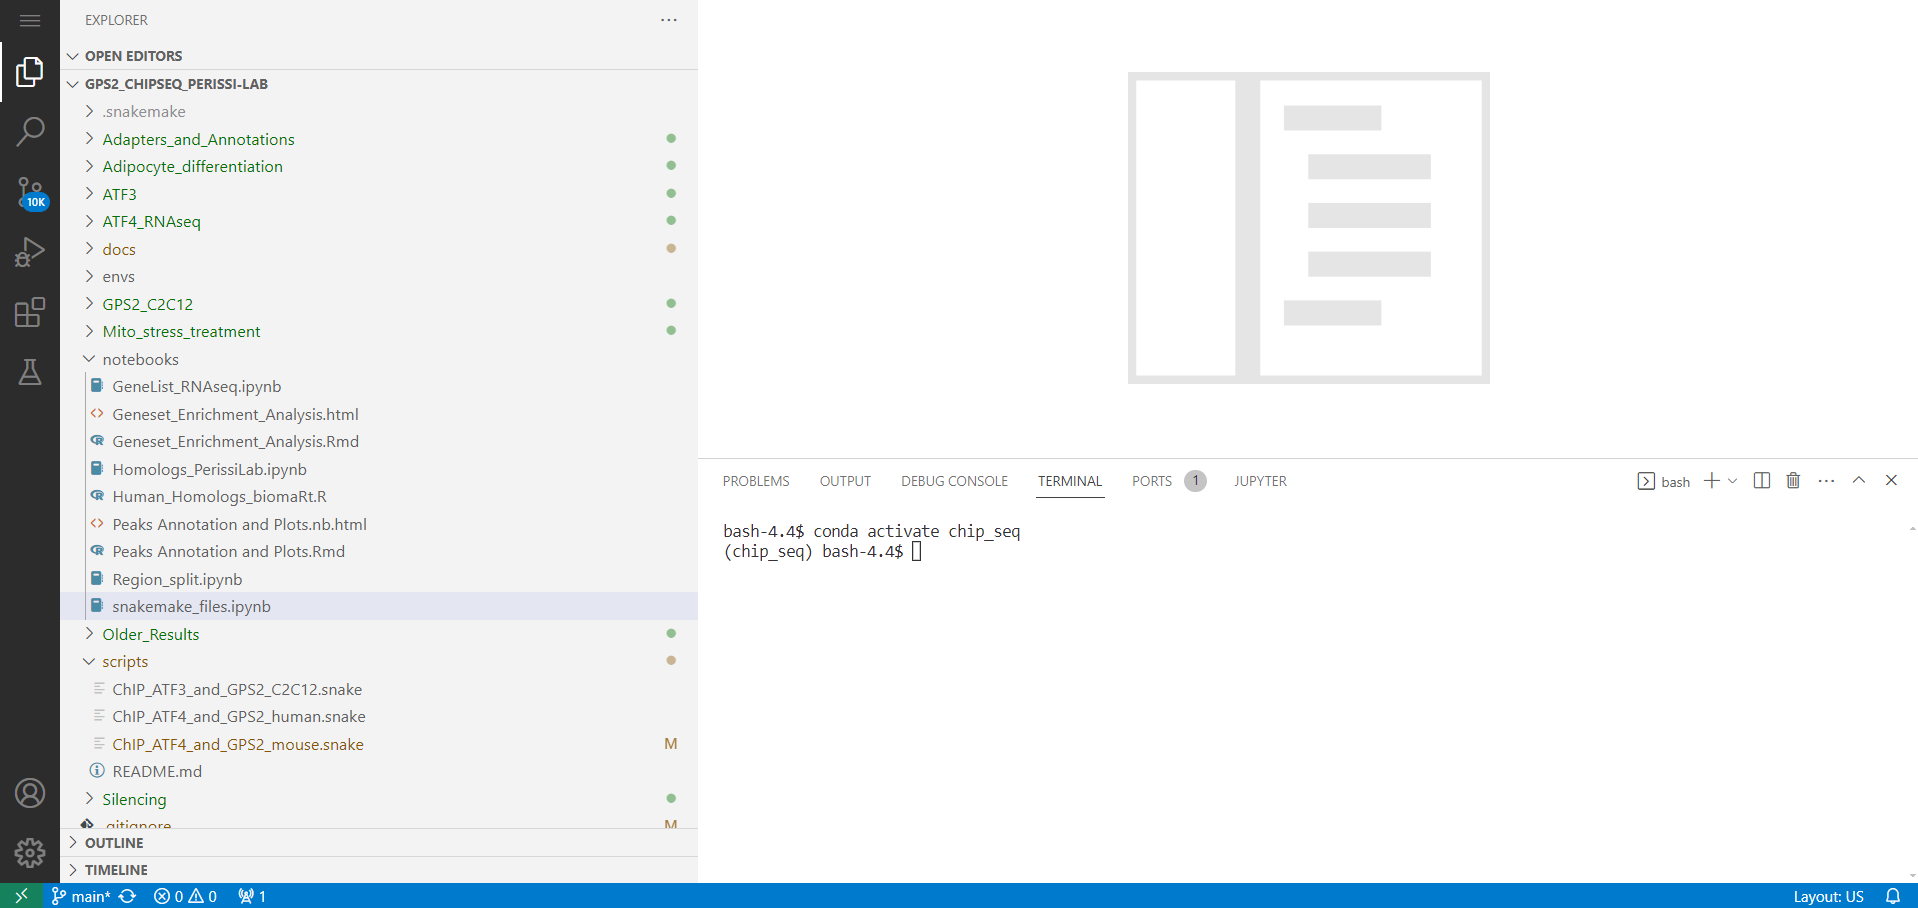

5. Now, the chip_seq environment is active and now you can execute your snakemake file by typing this first:

    This is called the Dry Run. Here, none of your results would be generated but is really helpful to see how many jobs you will be running and it will also tell you if there's any issues in your code.

    > snakemake -s scripts/ChIP_ATF4_and_GPS2_mouse.snake --sdm conda --executor cluster-generic --cluster-generic-submit-cmd "qsub -P perissilab -pe omp {threads}" --jobs 2 -np

    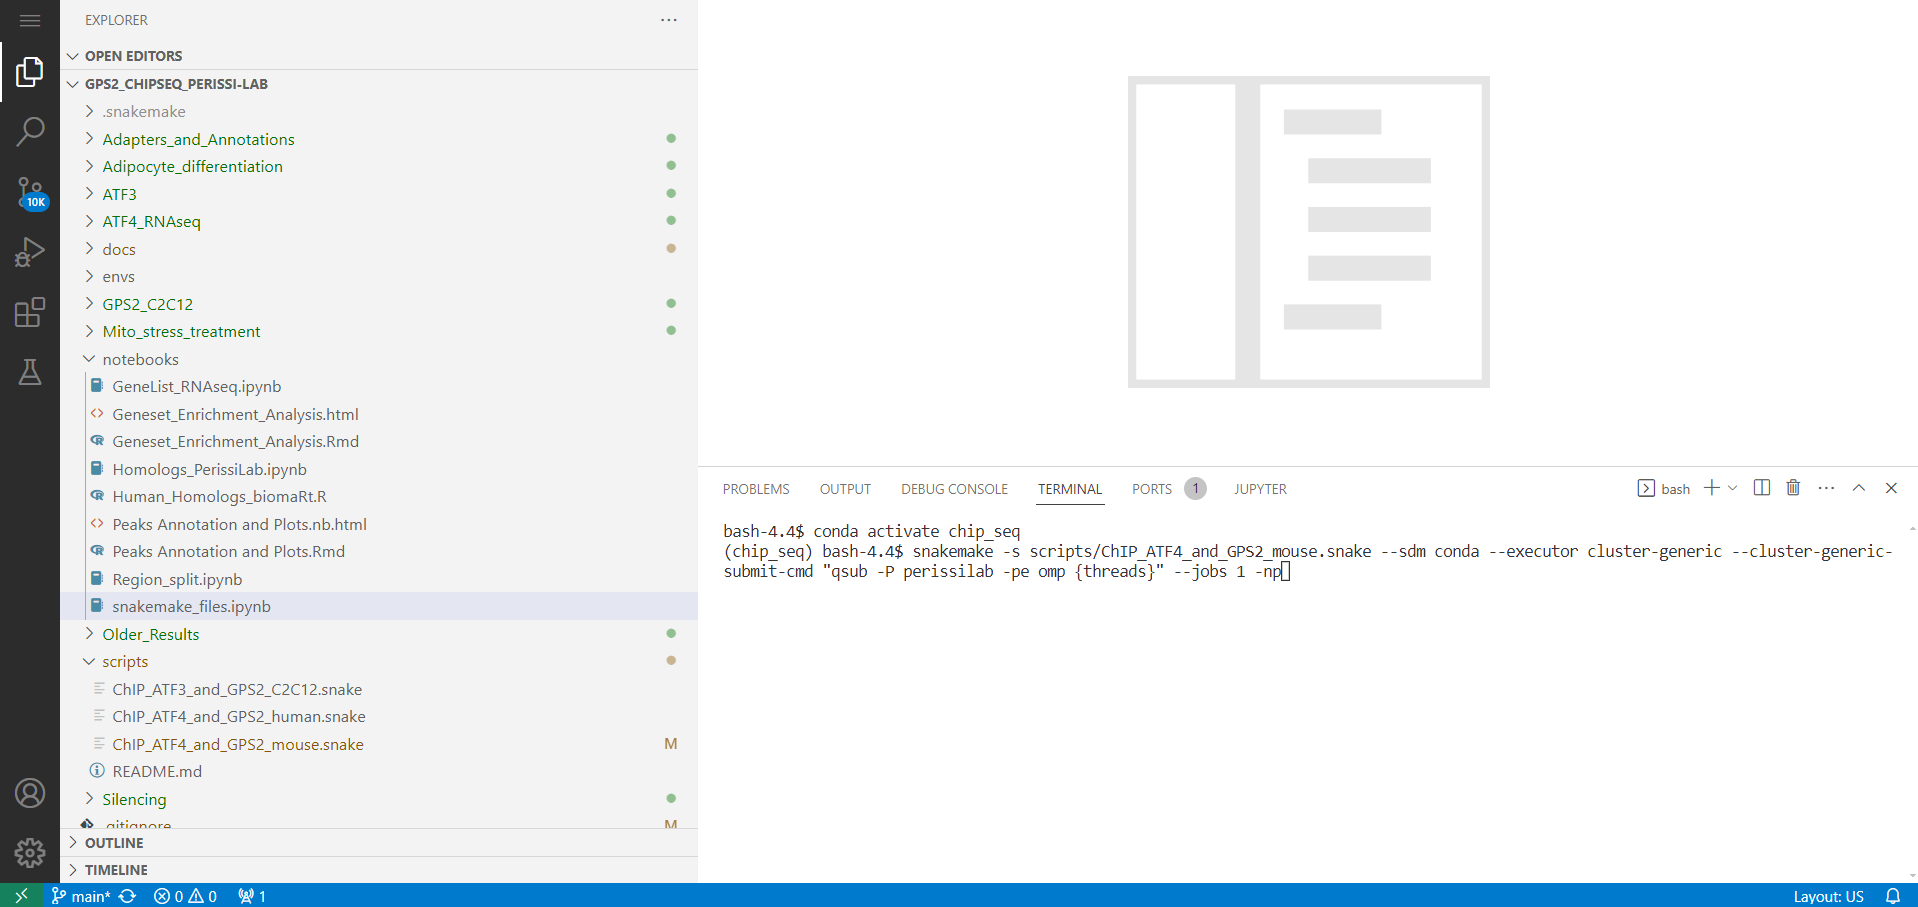
    
    This how it looks

    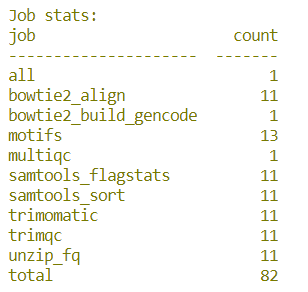

    Once you find the number of jobs, you can update it in the --jobs <> placeholder. For example, here, my dry run tells me, I have 82 jobs in total, so I modify my code as:

    > snakemake -s scripts/ChIP_ATF4_and_GPS2_mouse.snake --sdm conda --executor cluster-generic --cluster-generic-submit-cmd "qsub -P perissilab -pe omp {threads}" --jobs 84

This command should start generating all your results.

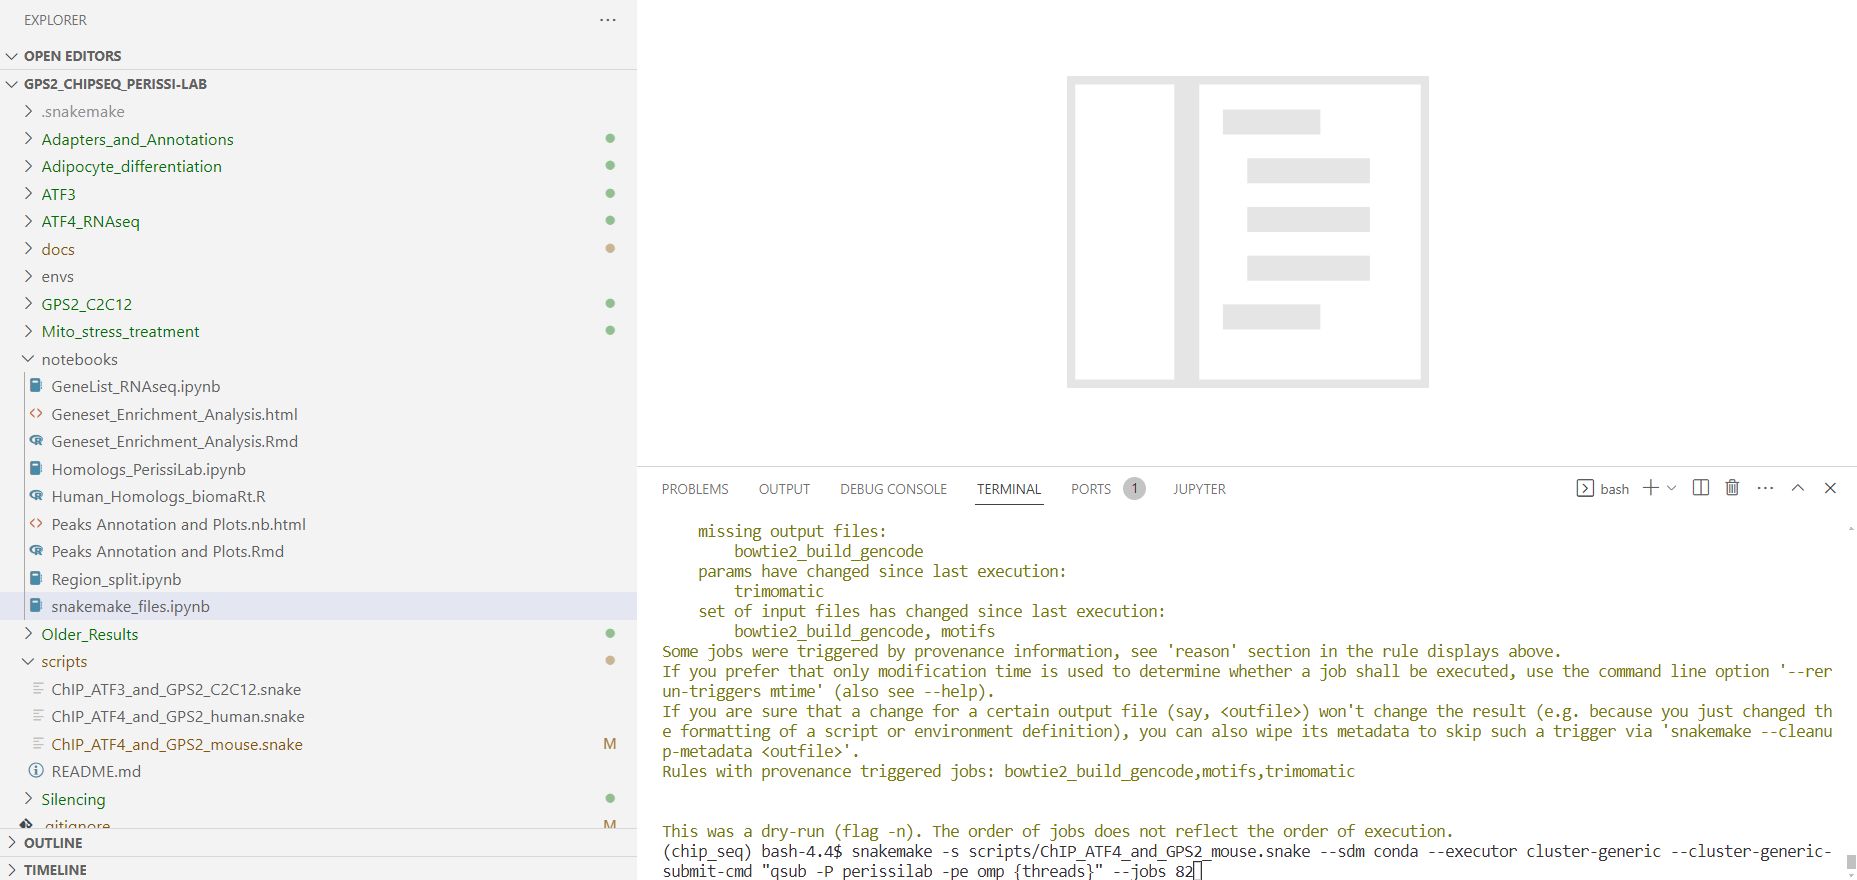

6. This is how the snakemake execution command is structured.

    > snakemake -s <snakemake_script_name> --sdm conda --executor cluster-generic --cluster-generic-submit-cmd "qsub -P perissilab -pe omp {threads}" --jobs <number_of_jobs> 

    Each script might have different number of jobs dependent on how much of the piepline is executed. So, it's always better to do dry run before executing the actual pipeline.